# Lab 2 — Exercise 6: SVM Classification of Landcover

Standalone notebook extracted from `761_Lab2_ans.ipynb` Exercise 6.

Shared Earth Engine / figure helpers live in `helpers/lab2_helpers.py` and can be imported by both this notebook and the main Lab 2 notebook.


# Set up


In [ ]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
# !pip install geemap --quiet


In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-dongwook') #<- Remember to change this to your own project's name!


In [2]:
# Import other libs
import zipfile
import tempfile
import urllib.request

import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from shapely.geometry import box
from sklearn.metrics import classification_report, f1_score

# Shared helpers (also usable from 761_Lab2_ans.ipynb)
from helpers.lab2_helpers import (
    mask_s2_clouds,
    get_sentinel2_for_year,
    add_indices,
    fc_to_lists,
    get_bounds_coords,
    add_scale_bar,
    add_north_arrow,
    LCDB_NAMES,
    LCDB_PALETTE,
)


(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



## Exercise 6: SVM Classification of Landcover


**HISTORY**
1. Baseline : Accuracy(0.5)+ macro F1 (0.09) , Random Sampling + numPixels:5000 (1455 samples)
2. Run 1 : Accuracy(0.32), Stratified Sampling + 300 numPoints
3. Run 2 : Accuracy(0.44), Run1 + Add more bands(features), Weak on spectrally similar woody/grass classes
4. Run 3 : Accuracy(0.52), Run2 + Add 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI', 'Class_2018'
5. Run 4 : Accuracy(0.45), Run1 + only 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI' indices

In [ ]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
# from google.colab import files
# uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("datasets/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("datasets/lcdb")



In [3]:

# Read shapefile
gdf = gpd.read_file("datasets/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names


In [4]:
display(gdf.head(3))

,Name_2018,Name_2012,Name_2008,Name_2001,Name_1996,Class_2018,Class_2012,Class_2008,Class_2001,Class_1996,...,Wetland_96,Onshore_18,Onshore_12,Onshore_08,Onshore_01,Onshore_96,EditAuthor,EditDate,LCDB_UID,geometry
0,Gravel or Rock,Gravel or Rock,Gravel or Rock,Gravel or Rock,Gravel or Rock,16,16,16,16,16,...,no,yes,yes,yes,yes,yes,Landcare Research,2004-06-30,lcdb2000021454,"POLYGON ((1339167.745 5005724.309, 1339080.897..."
1,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,41,41,41,41,41,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb2000069669,"POLYGON ((1333203.873 5130136.165, 1333144.138..."
2,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,54,54,54,54,54,...,no,yes,yes,yes,yes,yes,Landcare Research,2011-06-30,lcdb1000126743,"POLYGON ((1722346.367 6070406.526, 1722327.668..."


### 1. Fitering out 2018 landcover data

Select only 2018 data features along with the geometry.

In [5]:

columns = ['Name_2018','Class_2018','Wetland_18','Onshore_18','geometry']
gdf_cleaned = gdf[columns]
gdf_cleaned.to_crs(epsg=4326, inplace=True)  #Convert to EPSG 4326
display(gdf_cleaned.head(3))


,Name_2018,Class_2018,Wetland_18,Onshore_18,geometry
0,Gravel or Rock,16,no,yes,"POLYGON ((169.68748 -45.05388, 169.68635 -45.0..."
1,Low Producing Grassland,41,no,yes,"POLYGON ((169.67607 -43.93354, 169.67532 -43.9..."
2,Broadleaved Indigenous Hardwoods,54,no,yes,"POLYGON ((174.34901 -35.50238, 174.34881 -35.5..."


### 2. Get Sentinel-2 data for 2018

Area of Interest is the rectangle area of Great Barrier Island.  
- **base_bands** : Baseline feature bands used for training  
- **additional_bands** : Additional feature bands to improve model performance  

In [6]:

# Producing a landcover map of Great Barrier (Aotea) Island for 2018 
aoi = ee.Geometry.Rectangle([175.28, -36.35, 175.55, -36.02])

# baseline bands
base_bands = ['B2', 'B3', 'B4', 'B8']

# feature engineering(bands)
additional_bands = [ 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12']
bands = base_bands + additional_bands

# Resuse sentinel-2 extraction function from exercise 5
s2_date, s2_clipped = get_sentinel2_for_year(2018, aoi, bands)

# Add indices to the Sentinel-2 image, for more accurate classification
# (add_indices imported from helpers.lab2_helpers)
s2_clipped = add_indices(s2_clipped)


In [7]:
Map = geemap.Map(center=[-36.1953, 175.4372], zoom=10)
Map.addLayer(aoi, {}, 'AOI')
Map.addLayer(s2_clipped.select(base_bands), {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.2}, 'Sentinel-2 RGB')
# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-36.1953, 175.4372], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### 3. Clip Landcover dataset

Clip the landcover dataset to the AOI

In [39]:
from shapely.geometry import box


# Convert Earth Engine geometry to shapely geometry for clipping
# Get the coordinates from the Earth Engine geometry
minx, miny = 175.28, -36.35
maxx, maxy = 175.55, -36.02

# Create the bounding box geometry
bbox_polygon = box(minx, miny, maxx, maxy)

# 3. Clip the GeoDataFrame
gdf_clipped = gdf_cleaned.clip(bbox_polygon)

# Check the result
display(gdf_clipped.head())

,Name_2018,Class_2018,Wetland_18,Onshore_18,geometry
386340,Sand or Gravel,10,no,yes,"POLYGON ((175.30228 -36.23857, 175.30192 -36.2..."
154815,Low Producing Grassland,41,no,yes,"POLYGON ((175.30191 -36.2315, 175.30218 -36.23..."
212965,Manuka and/or Kanuka,52,no,yes,"POLYGON ((175.30717 -36.23287, 175.30722 -36.2..."
315994,Manuka and/or Kanuka,52,no,yes,"POLYGON ((175.302 -36.23397, 175.30177 -36.233..."
234868,Indigenous Forest,69,no,yes,"POLYGON ((175.4509 -36.30519, 175.45119 -36.30..."


### 4. Preparing Training Data

1. Convert the geopandas dataframe to the gee FeatureCollection.(Vector --> Feature)
2. Convert ee.Image to ee.FeatureCollection dataset
3. Count the number of samples per class to check for class imbalance.


In [40]:


# Convert the GeoDataFrame to Earth Engine FeatureCollection using geemap
landcover_fc = geemap.gdf_to_ee(gdf_clipped)

# Create a raster from the landcover vectors using the 'Class' field
landcover_raster = landcover_fc.reduceToImage(
    properties=['Class_2018'],
    reducer=ee.Reducer.first()
).rename('Class_2018')

# Add the landcover raster as a band to the Sentinel-2 image
training_data = s2_clipped.addBands(landcover_raster)

print("Available bands:", training_data.bandNames().getInfo())

Available bands: ['B2', 'B3', 'B4', 'B8', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI', 'Class_2018']


In [41]:
feature_bands = bands + ['NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI']

# Original sampling code from lab2. 
# ex6_sample = training_data.select(bands + ['Class_2018']).sample( 
#     region=aoi,
#     scale=10,
#     numPixels=5000,
#     seed=2,
#     geometries=True)

# use stratifiedSampling for balanced sampling
ex6_sample = training_data.select(feature_bands + ['Class_2018']).stratifiedSample(
    numPoints = 300,  # increase number of samples to prevent overfitting, initial : 100 with 2134 samples
    classBand='Class_2018',
    region=aoi,
    scale=10, #10 m scale from each land cover class within a region of interest
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
ex6_first_10 = ex6_sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(ex6_first_10['features']):
    props = feature['properties']
    # Print orignal bands and additional indices
    print(f"Sample {i+1}: Class={props['Class_2018']}, B2={props.get('B2'):.2f}, B3={props.get('B3'):.2f}, B4={props.get('B4'):.2f}, B8={props.get('B8'):.2f}, \
        NDVI={props.get('NDVI'):.2f}, NDWI={props.get('NDWI'):.2f}, NBR={props.get('NBR'):.2f}, NDMI={props.get('NDMI'):.2f}, EVI={props.get('EVI'):.2f}")

# Count number of samples per class (server-side)
ex6_class_counts = ex6_sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Class_2018'])

print('\nClass distribution in sample:')
print(ex6_class_counts.getInfo())


First 10 training samples:
Sample 1: Class=1, B2=0.02, B3=0.03, B4=0.02, B8=0.17,         NDVI=0.80, NDWI=-0.73, NBR=0.43, NDMI=0.15, EVI=0.33
Sample 2: Class=1, B2=0.04, B3=0.07, B4=0.04, B8=0.41,         NDVI=0.82, NDWI=-0.70, NBR=0.63, NDMI=0.39, EVI=0.67
Sample 3: Class=1, B2=0.03, B3=0.05, B4=0.05, B8=0.15,         NDVI=0.51, NDWI=-0.51, NBR=0.36, NDMI=0.14, EVI=0.20
Sample 4: Class=1, B2=0.06, B3=0.10, B4=0.07, B8=0.39,         NDVI=0.70, NDWI=-0.60, NBR=0.52, NDMI=0.28, EVI=0.60
Sample 5: Class=1, B2=0.02, B3=0.04, B4=0.04, B8=0.19,         NDVI=0.68, NDWI=-0.65, NBR=0.30, NDMI=0.11, EVI=0.31
Sample 6: Class=1, B2=0.03, B3=0.04, B4=0.02, B8=0.03,         NDVI=0.21, NDWI=0.13, NBR=0.23, NDMI=0.02, EVI=0.03
Sample 7: Class=1, B2=0.03, B3=0.06, B4=0.03, B8=0.41,         NDVI=0.87, NDWI=-0.75, NBR=0.68, NDMI=0.42, EVI=0.70
Sample 8: Class=1, B2=0.04, B3=0.06, B4=0.05, B8=0.17,         NDVI=0.52, NDWI=-0.50, NBR=0.38, NDMI=0.22, EVI=0.25
Sample 9: Class=1, B2=0.03, B3=0.04, B4=0.03,

### 4. Split the training dataset to Train and Test
I am using only training and test datasets; validation dataset is not required as parameter tunning is not the outside the scope of this stage.

In [42]:
# Add random column
ex6_sample = ex6_sample.randomColumn('random',seed=2)

# Split
ex6_train = ex6_sample.filter(ee.Filter.lt('random', 0.8))
ex6_test = ex6_sample.filter(ee.Filter.gte('random', 0.8))

# number of samples
print(f"Number of total samples: {ex6_sample.size().getInfo()}")

Number of total samples: 6029


### 5. Training the SVM Model

1. Use the predefined hyperparameters in lab2 
2. Extract the ground-truth and predicted y-values from the trained model

In [43]:
# Define and train the SVM classifier
class_property = 'Class_2018'
ex6_svm = ee.Classifier.libsvm(kernelType='RBF',gamma=0.5,cost=10).train(
    features=ex6_train,
    classProperty=class_property,
    inputProperties=feature_bands
)

# Classify validation and test sets
ex6_test_classified = ex6_test.classify(ex6_svm)



In [44]:
# return true and predicted values
y_true, y_pred = fc_to_lists(ex6_test_classified, 'Class_2018', 'classification')
assert len(y_true) == len(y_pred), "y_true and y_pred have different lengths"


### 6. Evaludate the Performance of the SVM Model  

1. Fetch unique class names
2. Generate the error matrix from the trained classified model.
3. Print the confusion matrix, and generate the classification report using the scikit-learn API 


In [45]:
# order of classes in test dataset. I don't want to print all of them, which is not exist in the test dataset
ex6_order = ex6_test.aggregate_array('Class_2018').distinct().sort() 

# use errorMatrix in google earth engine
ex6_test_matrix = ex6_test_classified.errorMatrix(class_property, 'classification',ex6_order)


In [46]:
# From lcdb-classes-at-version5.pdf (short names) — LCDB_NAMES imported from helpers

# List up only exist labels
labels = ex6_order.getInfo() 
names = [LCDB_NAMES.get(int(l), str(l))+'('+str(l)+')' for l in labels] 

print("Confusion Matrix:")
display(pd.DataFrame(ex6_test_matrix.getInfo(), index=names, columns=names))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=names))


Confusion Matrix:


,Built-up Area(1),Urban Parkland/Open Space(2),Transport Infrastructure(5),Surface Mine or Dump(6),Sand or Gravel(10),Landslide(12),Gravel or Rock(16),Lake or Pond(20),River(21),Estuarine Open Water(22),...,Low Producing Grassland(41),Herbaceous Freshwater Vegetation(45),Herbaceous Saline Vegetation(46),Gorse and/or Broom(51),Manuka and/or Kanuka(52),Broadleaved Indigenous Hardwoods(54),Forest - Harvested(64),Indigenous Forest(69),Mangrove(70),Exotic Forest(71)
Built-up Area(1),24,4,0,0,2,0,1,0,1,1,...,1,0,0,3,0,0,0,1,0,2
Urban Parkland/Open Space(2),2,36,8,1,0,0,0,0,0,0,...,0,1,0,0,0,0,8,0,0,0
Transport Infrastructure(5),1,2,50,0,1,0,0,0,0,0,...,1,9,0,2,2,0,7,0,0,0
Surface Mine or Dump(6),4,0,0,27,1,0,2,0,0,0,...,0,1,0,0,1,0,0,0,0,0
Sand or Gravel(10),5,3,2,1,17,0,16,0,1,2,...,1,0,2,3,4,0,4,0,0,1
Landslide(12),0,0,0,1,7,3,2,0,0,0,...,0,0,0,0,0,0,0,0,0,5
Gravel or Rock(16),6,1,0,0,4,0,43,0,0,0,...,0,5,0,0,1,0,6,1,0,1
Lake or Pond(20),0,0,0,0,0,0,0,2,0,0,...,0,2,0,0,3,0,0,0,1,0
River(21),0,0,0,2,0,0,0,0,28,7,...,0,1,2,0,0,0,0,0,2,2
Estuarine Open Water(22),0,0,0,0,0,0,0,0,2,54,...,0,0,0,0,0,0,0,0,3,0



Classification Report:
                                        precision    recall  f1-score   support

                      Built-up Area(1)       0.34      0.46      0.39        52
          Urban Parkland/Open Space(2)       0.49      0.55      0.51        66
           Transport Infrastructure(5)       0.55      0.67      0.60        75
               Surface Mine or Dump(6)       0.82      0.75      0.78        36
                    Sand or Gravel(10)       0.47      0.27      0.34        63
                         Landslide(12)       1.00      0.17      0.29        18
                    Gravel or Rock(16)       0.62      0.63      0.63        68
                      Lake or Pond(20)       0.67      0.25      0.36         8
                             River(21)       0.72      0.64      0.67        44
              Estuarine Open Water(22)       0.82      0.92      0.86        59
Orchards/Vineyards/Perennial Crops(33)       0.56      0.69      0.62        71
   High Produci

### 7. Figure map of the SVM model

Apply the trained SVM to the full 2018 Sentinel-2 composite and inspect the classified map interactively, then present it as a publication-quality figure with a scale bar, north arrow, legend, data attribution and the model's performance statistics.

In [47]:
# Apply the trained SVM to every pixel of the 2018 composite
ex6_classified = s2_clipped.select(feature_bands).classify(ex6_svm)

# Quick interactive look before committing to the publication figure
Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(s2_clipped, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3, 'gamma': 1.2}, 'Sentinel-2 RGB 2018')
Map.addLayer(ex6_classified.randomVisualizer(), {}, 'SVM landcover 2018')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-36.184959926082875, 175.41500000000002], controls=(WidgetControl(options=['position', 'transparen…

#### Publication-quality figure

LCDB class codes are sparse (0, 1, 2, 5, 10, ... 80), so they are remapped onto 1...N before a palette can be applied. Each code keeps a fixed colour so a class looks the same in every figure.

In [48]:
# Official LCDB v5.0 symbology colours — LCDB_PALETTE imported from helpers

# The SVM can only predict classes seen in the training split
ex6_classes = [int(c) for c in ex6_train.aggregate_array('Class_2018').distinct().sort().getInfo()]
ex6_index = list(range(1, len(ex6_classes) + 1))
ex6_palette = [LCDB_PALETTE.get(c, '888888') for c in ex6_classes]

ex6_classified_vis = ex6_classified.remap(ex6_classes, ex6_index)
ex6_vis_params = {'min': 1, 'max': len(ex6_classes), 'palette': ex6_palette}

# Restrict the legend to classes that actually appear on the map
ex6_hist = ex6_classified.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=100,
    maxPixels=1e9,
).getInfo()['classification']
ex6_mapped = [c for c in ex6_classes if str(c) in ex6_hist or f'{c}.0' in ex6_hist]

# Thumbnails: true colour uses the same 0-0.3 reflectance stretch as the rest of the lab
ex6_xmin, ex6_xmax, ex6_ymin, ex6_ymax = get_bounds_coords(aoi)
ex6_thumb_params = {'dimensions': 600, 'region': aoi, 'format': 'png'} # hitting timeout on the high dimensions

ex6_rgb_url = s2_clipped.visualize(
    bands=['B4', 'B3', 'B2'], min=0, max=0.3, gamma=1.2
).getThumbURL(ex6_thumb_params)
ex6_class_url = ex6_classified_vis.visualize(**ex6_vis_params).getThumbURL(ex6_thumb_params)



In [49]:
# Performance statistics reported inside the figure
ex6_oa = ex6_test_matrix.accuracy().getInfo()
ex6_kappa = ex6_test_matrix.kappa().getInfo()
ex6_macro_f1 = f1_score(y_true, y_pred, average='macro')
ex6_n_train = ex6_train.size().getInfo()
ex6_n_test = ex6_test.size().getInfo()

print(f'Classes predictable by the SVM: {len(ex6_classes)}  |  classes present on the map: {len(ex6_mapped)}')
print(f'Overall accuracy {ex6_oa:.3f}  |  kappa {ex6_kappa:.3f}  |  macro F1 {ex6_macro_f1:.3f}')

# add_scale_bar / add_north_arrow imported from helpers.lab2_helpers


Classes predictable by the SVM: 22  |  classes present on the map: 22
Overall accuracy 0.515  |  kappa 0.490  |  macro F1 0.492


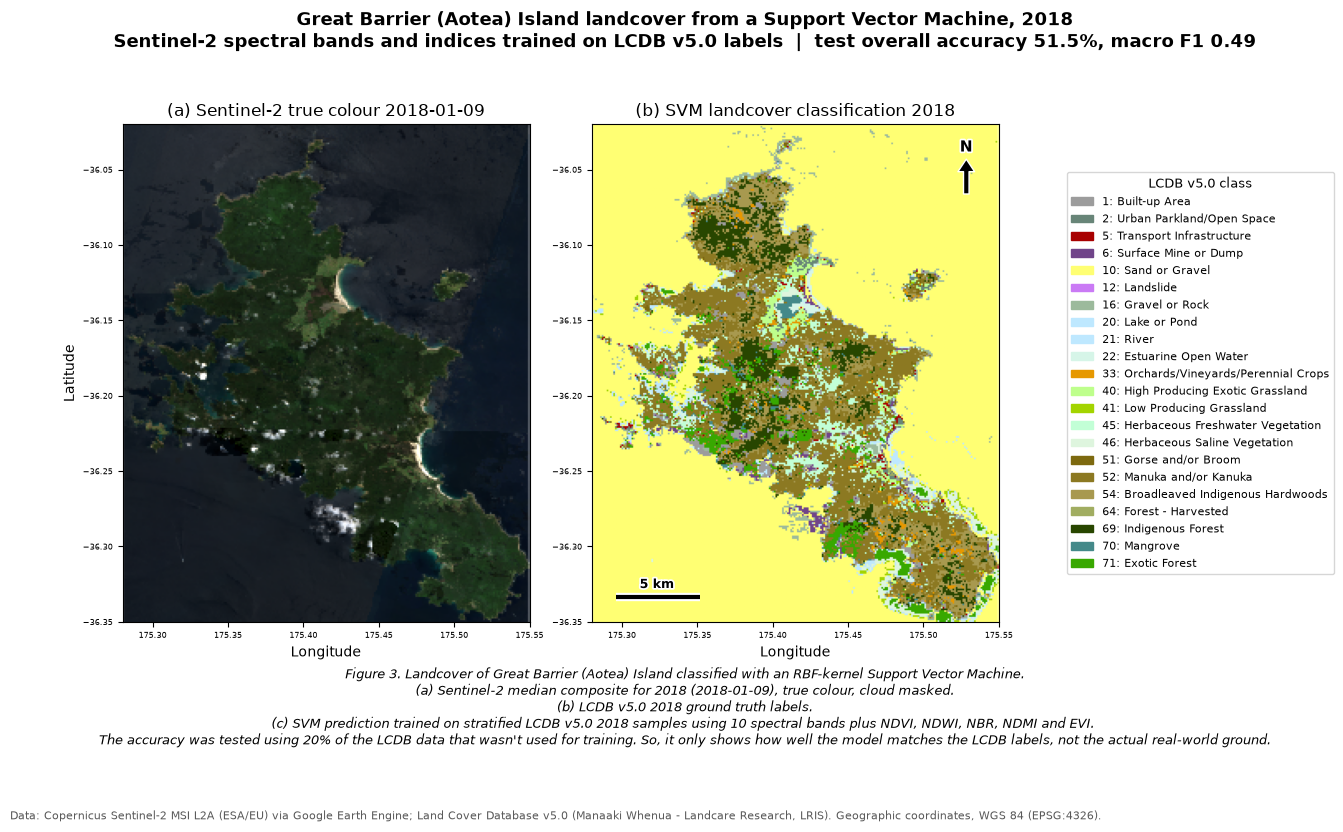

In [62]:
# --- Figure layout: 2 maps + legend column (Lab 1 / Lab 2: fig + gridspec) ---
fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.55], wspace=0.18)
ax_rgb = fig.add_subplot(gs[0, 0])
ax_class = fig.add_subplot(gs[0, 1])
ax_legend = fig.add_subplot(gs[0, 2])

panels = (
    (ax_rgb, ex6_rgb_url, f'(a) Sentinel-2 true colour {s2_date}'),
    (ax_class, ex6_class_url, '(b) SVM landcover classification 2018'),
)
for ax, url, title in panels:
    with tempfile.NamedTemporaryFile(suffix='.png') as f:
        urllib.request.urlretrieve(url, f.name)
        img = mpimg.imread(f.name)
        ax.imshow(img, extent=[ex6_xmin, ex6_xmax, ex6_ymin, ex6_ymax])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_xlim(ex6_xmin, ex6_xmax)
    ax.set_ylim(ex6_ymin, ex6_ymax)
    ax.tick_params(labelsize=6)

ax_rgb.set_ylabel('Latitude', fontsize=10)

# Map furniture on the classified panel
add_scale_bar(ax_class, length_km=5)
add_north_arrow(ax_class)

# Legend column: only the classes present on the map
ax_legend.axis('off')
legend_patches = [
    mpatches.Patch(color=f'#{LCDB_PALETTE.get(c, "888888")}', label=f'{c}: {LCDB_NAMES.get(c, str(c))}')
    for c in ex6_mapped
]
ax_legend.legend(
    handles=legend_patches,
    loc='center left',
    ncol=1,
    fontsize=8,
    frameon=True,
    title='LCDB v5.0 class',
    title_fontsize=9,
)

fig.suptitle(
    'Great Barrier (Aotea) Island landcover from a Support Vector Machine, 2018\n'
    f'Sentinel-2 spectral bands and indices trained on LCDB v5.0 labels  |  '
    f'test overall accuracy {ex6_oa:.1%}, macro F1 {ex6_macro_f1:.2f}',
    fontsize=13,
    fontweight='bold',
)

fig.text(
    0.5, 0.0,
    'Figure 3. Landcover of Great Barrier (Aotea) Island classified with an RBF-kernel Support Vector Machine.\n'
    f'(a) Sentinel-2 median composite for 2018 ({s2_date}), true colour, cloud masked.\n'
    '(b) LCDB v5.0 2018 ground truth labels.\n'
    '(c) SVM prediction trained on stratified LCDB v5.0 2018 samples using 10 spectral bands plus NDVI, NDWI, NBR, NDMI and EVI. \n'
    'The accuracy was tested using 20% of the LCDB data that wasn\'t used for training. So, it only shows how well the model matches the LCDB labels, not the actual real-world ground.',
    ha='center', fontsize=9, style='italic',
)

fig.text(
    0.1, -0.1,
    'Data: Copernicus Sentinel-2 MSI L2A (ESA/EU) via Google Earth Engine; '
    'Land Cover Database v5.0 (Manaaki Whenua - Landcare Research, LRIS). '
    'Geographic coordinates, WGS 84 (EPSG:4326).',
    ha='left', fontsize=8, color='0.35',
)

plt.tight_layout()
fig.savefig('figures/lab2_ex6_aotea_svm_landcover_2018.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
# LCDB label map for panel (c): landcover_raster is an Image, so remap + visualize work.
ex6_label_classes = [int(c) for c in ex6_sample.aggregate_array('Class_2018').distinct().sort().getInfo()]
ex6_label_index = list(range(1, len(ex6_label_classes) + 1))
ex6_label_palette = [LCDB_PALETTE.get(c, '888888') for c in ex6_label_classes]

ex6_label_vis = landcover_raster.remap(ex6_label_classes, ex6_label_index)
ex6_classified_vis = ex6_classified.remap(ex6_label_classes, ex6_label_index)

ex6_thumb_params = {'dimensions': 300, 'region': aoi, 'format': 'png'}
ex6_vis_params = {'min': 1, 'max': len(ex6_label_classes), 'palette': ex6_label_palette}

# Thumbnails: true colour uses the same 0-0.3 reflectance stretch as the rest of the lab
ex6_xmin, ex6_xmax, ex6_ymin, ex6_ymax = get_bounds_coords(aoi)

# True color
ex6_rgb_url = s2_clipped.visualize(
    bands=['B4', 'B3', 'B2'], min=0, max=0.3, gamma=1.2
).getThumbURL(ex6_thumb_params)

# SVM classification
ex6_class_url = ex6_classified_vis.visualize(**ex6_vis_params).getThumbURL(ex6_thumb_params)

# Actual landcover label
ex6_sample_class_url = ex6_label_vis.visualize(**ex6_vis_params).getThumbURL(ex6_thumb_params)




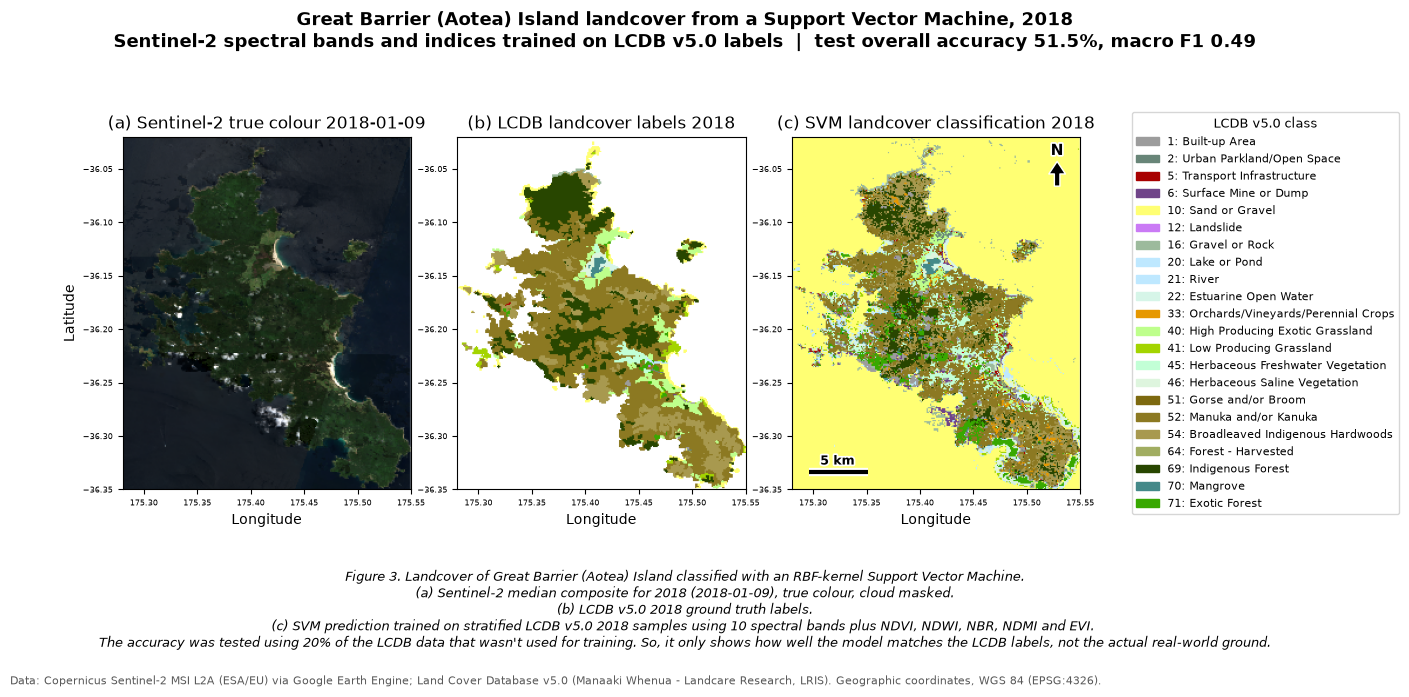

In [ ]:
# --- Figure layout: 3 maps + legend column (Lab 1 / Lab 2: fig + gridspec) ---
fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.55], wspace=0.18)
ax_rgb = fig.add_subplot(gs[0, 0])
ax_sample = fig.add_subplot(gs[0, 1])
ax_class = fig.add_subplot(gs[0, 2])
ax_legend = fig.add_subplot(gs[0, 3])

panels = (
    (ax_rgb, ex6_rgb_url, f'(a) Sentinel-2 true colour {s2_date}'),
    (ax_sample, ex6_sample_class_url, '(b) LCDB landcover labels 2018'),
    (ax_class, ex6_class_url, '(c) SVM landcover classification 2018'),
)
for ax, url, title in panels:
    with tempfile.NamedTemporaryFile(suffix='.png') as f:
        urllib.request.urlretrieve(url, f.name)
        img = mpimg.imread(f.name)
        ax.imshow(img, extent=[ex6_xmin, ex6_xmax, ex6_ymin, ex6_ymax])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_xlim(ex6_xmin, ex6_xmax)
    ax.set_ylim(ex6_ymin, ex6_ymax)
    ax.tick_params(labelsize=6)

ax_rgb.set_ylabel('Latitude', fontsize=10)

# Map furniture on the classified panel
add_scale_bar(ax_class, length_km=5)
add_north_arrow(ax_class)

# Legend column: only the classes present on the map
ax_legend.axis('off')
legend_patches = [
    mpatches.Patch(color=f'#{LCDB_PALETTE.get(c, "888888")}', label=f'{c}: {LCDB_NAMES.get(c, str(c))}')
    for c in ex6_classes
]
ax_legend.legend(
    handles=legend_patches,
    loc='center left',
    ncol=1,
    fontsize=8,
    frameon=True,
    title='LCDB v5.0 class',
    title_fontsize=9,
)

fig.suptitle(
    'Great Barrier (Aotea) Island landcover from a Support Vector Machine, 2018\n'
    f'Sentinel-2 spectral bands and indices trained on LCDB v5.0 labels  |  '
    f'test overall accuracy {ex6_oa:.1%}, macro F1 {ex6_macro_f1:.2f}',
    fontsize=13,
    fontweight='bold',
    y=0.9
)

fig.text(
    0.5, 0.05,
    'Figure 3. Landcover of Great Barrier (Aotea) Island classified with an RBF-kernel Support Vector Machine.\n'
    f'(a) Sentinel-2 median composite for 2018 ({s2_date}), true colour, cloud masked.\n'
    '(b) LCDB v5.0 2018 ground truth labels.\n'
    '(c) SVM prediction trained on stratified LCDB v5.0 2018 samples using 10 spectral bands plus NDVI, NDWI, NBR, NDMI and EVI. \n'
    'The accuracy was tested using 20% of the LCDB data that wasn\'t used for training. So, it only shows how well the model matches the LCDB labels, not the actual real-world ground.',
    ha='center', fontsize=9, style='italic',
)

fig.text(
    0.1, 0.00,
    'Data: Copernicus Sentinel-2 MSI L2A (ESA/EU) via Google Earth Engine; '
    'Land Cover Database v5.0 (Manaaki Whenua - Landcare Research, LRIS). '
    'Geographic coordinates, WGS 84 (EPSG:4326).',
    ha='left', fontsize=8, color='0.35',
)

plt.tight_layout()
fig.savefig('figures/lab2_ex6_aotea_svm_landcover_2018_2.png', dpi=300, bbox_inches='tight')
plt.show()
